#Histogram Assignment

Sanjeev K(ph25mscst11026)

In [2]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const

#Q. 1)
 Please use the histogram code that you have developed in the class. Use the heights for the height that
has been shared on the Google classroom and show the PDF plot and add a comment about the
observation.

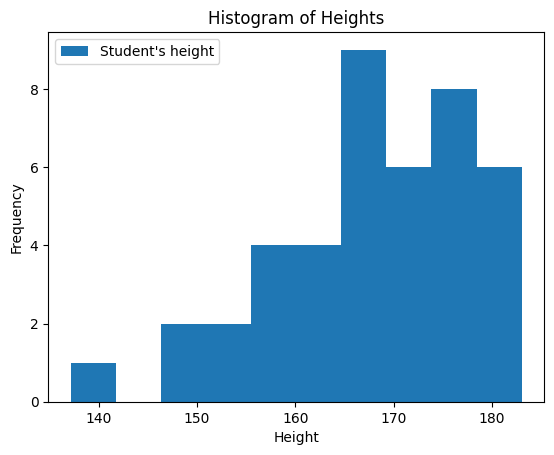

The mean height is 167.67904761904762 cm.
The standard deviation is 9.994697596493427 cm.


In [5]:
# load and read the data
x = np.loadtxt('/content/Height.xlsx')

xmin = np.min(x)
xmax = np.max(x)

bins = 10
edge = np.linspace(xmin, xmax, bins+1)
bin_width = (xmax - xmin)/bins

def my_histogram(x, bins):
    counts = np.zeros(bins)

    for xi in x:

        # handle last bin explicitly
        if xi == xmax:
            counts[-1] += 1
            continue

        for i in range(bins):
            if edge[i] <= xi < edge[i+1]:
                counts[i] += 1
                break

    return counts


counts = my_histogram(x, bins)
centers = edge[:-1] + bin_width/2

plt.bar(centers, counts, width=bin_width, label="Student's height")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Histogram of Heights")
plt.legend()
plt.show()

print(f"The mean height is {np.mean(x)} cm.")
print(f"The standard deviation is {np.std(x)} cm.")


#Comment
The histogram shows that Most students have heights between 160 cm and 180 cm, indicating that the data is concentrated near the mean. Very few students lie at the extreme ends (very short or very tall). Hence, the height distribution appears nearly normal.

#Q. 2)
“gaussian_random_numbers.xlsx” is shared along with this assignment. It contains three columns
with the data of $‘x’$, $‘y’$, $‘z’$ component of the velocity. Show the PDF of all the three velocity. Comment
about the mean and variance. Suppose these are the velocity fields of the gas molecules at the room
temperature, extract the room temperature from this data. From this calculate the PDF of $|V_x|$ and
$v = \sqrt{x^2 + y^2 + z^2}$. From the data calculate the most probable speed and root mean speed.
Compare it against the estimated value from the temperature that one would get from the
temperature.

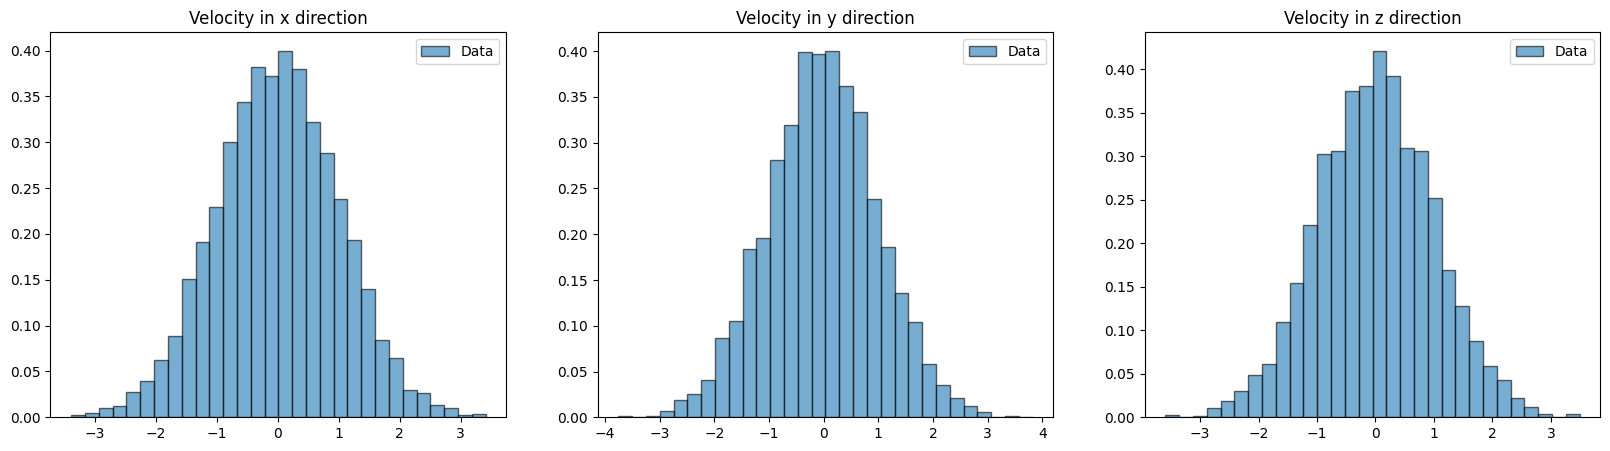

In [ ]:
#read and extract data from the given file
df = pd.read_excel("/content/gaussian_random_numbers.xlsx")
data = df.to_numpy()
v_x = data[:, 0]
v_y = data[:, 1]
v_z = data[:, 2]

#plotting the pdf of all the three component velocity
fig, ax = plt.subplots(1, 3, figsize = (20, 5))
ax[0].hist(v_x, bins=30, density=True, alpha=0.6, edgecolor='black', label="Data")
ax[0].set_title("Velocity in x direction")
ax[0].legend()

ax[1].hist(v_y, bins=30, density=True, alpha=0.6, edgecolor='black', label="Data")
ax[1].set_title("Velocity in y direction")
ax[1].legend()

ax[2].hist(v_z, bins=30, density=True, alpha=0.6, edgecolor='black', label="Data")
ax[2].set_title("Velocity in z direction")
ax[2].legend()

plt.show()

As seen from the graphs, the velocity distributions in all three directions follow a Gaussian distribution.

The histograms of $v_x$ , $v_y$ & $v_z$ are symmetric and centered about zero, indicating that the mean velocity in each direction is approximately zero The spreads of the three distributions are nearly identical, implying that the variances are equal in all directions. This confirms isotropic motion of gas molecules and indicates that the kinetic energy (and hence temperature) is equally distributed among the three components.

In [ ]:

#velocity
v = np.sqrt(v_x**2 + v_y**2 + v_z**2)

#mean of the each velocity component
vx_mean = np.mean(v_x)
vy_mean = np.mean(v_y)
vz_mean = np.mean(v_z)

#variance of the each velocity componet
vx_var = np.mean(v_x ** 2) - np.mean(v_x) ** 2
vy_var = np.mean(v_y ** 2) - np.mean(v_y) ** 2
vz_var = np.mean(v_z ** 2) - np.mean(v_z) ** 2

#sigma square
sigma2 = (vx_var + vy_var + vz_var)/3

#set values
K = 1        # Boltzmann constant (J/K)
m = 1

#calculating v_mp and v_rms values from the given data
counts, edges = np.histogram(v, bins=30)

v_mp_data = edges[np.argmax(counts)] #most probable speed
print("Most probable speed (data) =", v_mp_data)

v_rms_data = np.sqrt(np.mean(v**2)) #root mean square speed
print("RMS speed (data) =", v_rms_data)


#calculating Temprature
T = m * sigma2 / K

#calculating most probable and root mean square speed using temprature

v_mp = np.sqrt(2 * K * T / m)      #most probable speed(maxima of PDF)
v_rms = np.sqrt(3 * K * T / m)     #RMS speed

print("Temprature:", T)
print("Most Probable Speed:", v_mp)
print("RMS Speed:", v_rms)

Most probable speed (data) = 1.2304043530445767
RMS speed (data) = 1.7301492223631934
Temprature: 0.9976640468271927
Most Probable Speed: 1.412560828302408
RMS Speed: 1.7300266299920293


Histogram of $|v_x|$ ,$|v_y|$ and $|v_z|$

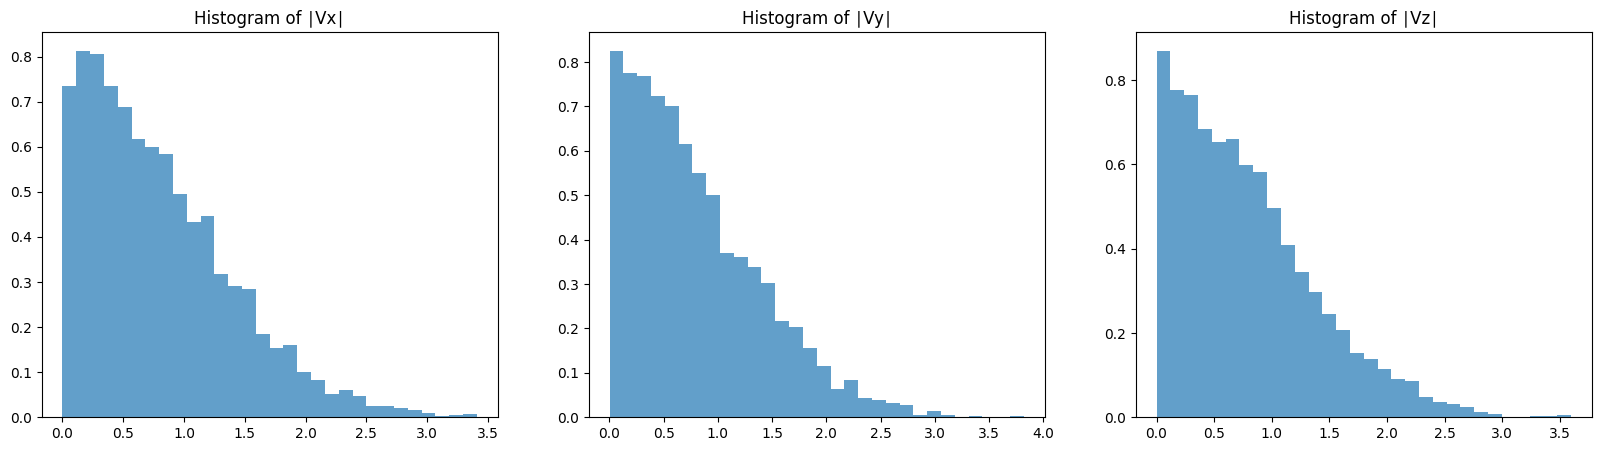

In [ ]:
vx_abs = np.abs(v_x)
vy_abs = np.abs(v_y)
vz_abs = np.abs(v_z)


fig, ax = plt.subplots(1, 3, figsize = (20,5))
ax[0].hist(vx_abs, bins=30, density=True, alpha=0.7)
ax[0].set_title("Histogram of ∣Vx​∣")

ax[1].hist(vy_abs, bins=30, density=True, alpha=0.7)
ax[1].set_title("Histogram of ∣Vy∣")

ax[2].hist(vz_abs, bins=30, density=True, alpha=0.7)
ax[2].set_title("Histogram of ∣Vz​∣")

plt.show()

#Maxwell Boltzmann Speed Distribution

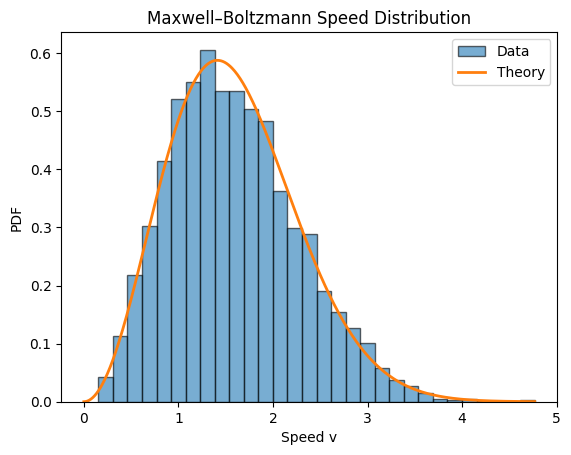

In [ ]:
v_space = np.linspace(0, max(v), 500)

# #defining theoritical curve(Maxwell–Boltzmann speed distribution)
def f(v):
    A = 4*np.pi * (m/(2*np.pi*K*T))**(3/2)
    return A * v**2 * np.exp(-m*v**2/(2*K*T))

plt.hist(v, bins=30, density=True, alpha=0.6, edgecolor='black', label="Data")
plt.plot(v_space, f(v_space), linewidth=2, label="Theory")

plt.xlabel("Speed v")
plt.ylabel("PDF")
plt.legend()
plt.title("Maxwell–Boltzmann Speed Distribution")
plt.show()


Using the variance, we calculated the Temprature. The speed distribution follows the Maxwell–Boltzmann distribution. The most probable and RMS speeds calculated from data agree well with theoretical predictions, validating kinetic theory of gases.

In [ ]:
#I really enjoyed doing this Assignment:)